# Implement Federated Learning with Differential Privacy
**Step 1 – Install Required Libraries**

In [ ]:
!pip install torch torchvision numpy matplotlib

**Step 2 – Import Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt

**Step 3 – Load Dataset (MNIST)**

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.75MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.14MB/s]


**Step 4 – Simulate Federated Clients**

We divide the dataset among multiple clients.

In [ ]:
NUM_CLIENTS = 5

data_per_client = len(trainset) // NUM_CLIENTS

client_datasets = []

for i in range(NUM_CLIENTS):
    start = i * data_per_client
    end = start + data_per_client
    subset = torch.utils.data.Subset(trainset, range(start, end))
    client_datasets.append(subset)

**Step 5 – Define Neural Network Model**

In [ ]:
class SimpleNN(nn.Module):

    def __init__(self):
        super(SimpleNN,self).__init__()

        self.fc1 = nn.Linear(28*28,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self,x):

        x = x.view(-1,28*28)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

**Step 6 – Differential Privacy: Add Noise to Gradients**

Gaussian noise is added to protect user data.

In [ ]:
def add_dp_noise(model, noise_scale):

    for param in model.parameters():
        noise = torch.normal(0, noise_scale, size=param.grad.shape)
        param.grad += noise

**Step 7 – Local Client Training**

In [ ]:
def train_client(model, dataset, epochs=1, noise_scale=0.1):

    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    model.train()

    for epoch in range(epochs):

        for images, labels in loader:

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()

            # Add DP noise
            add_dp_noise(model, noise_scale)

            optimizer.step()

    return model.state_dict()

**Step 8 – Federated Averaging (FedAvg)**

In [ ]:
def federated_average(global_model, client_weights):

    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        global_dict[key] = torch.stack(
            [client_weights[i][key] for i in range(len(client_weights))],0
        ).mean(0)

    global_model.load_state_dict(global_dict)

    return global_model

**Step 9 – Federated Training Loop**

In [ ]:
global_model = SimpleNN()

ROUNDS = 10
noise_scale = 0.2   # controls privacy level

accuracy_list = []

for round in range(ROUNDS):

    client_weights = []

    for client in range(NUM_CLIENTS):

        local_model = SimpleNN()
        local_model.load_state_dict(global_model.state_dict())

        weights = train_client(local_model, client_datasets[client],
                               epochs=1,
                               noise_scale=noise_scale)

        client_weights.append(weights)

    global_model = federated_average(global_model, client_weights)

    print("Round",round,"completed")

Round 0 completed
Round 1 completed
Round 2 completed
Round 3 completed
Round 4 completed
Round 5 completed
Round 6 completed
Round 7 completed
Round 8 completed
Round 9 completed


**Step 10 – Model Evaluation**

In [ ]:
testloader = torch.utils.data.DataLoader(testset, batch_size=1000)

correct = 0
total = 0

global_model.eval()

with torch.no_grad():

    for images, labels in testloader:

        outputs = global_model(images)
        _, predicted = torch.max(outputs.data,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:",accuracy)

Test Accuracy: 90.85


**Step 11 – Accuracy vs Privacy Experiment**

In [ ]:
noise_levels = [0.0,0.1,0.3,0.5]

results = []

for noise in noise_levels:

    global_model = SimpleNN()

    for round in range(5):

        client_weights=[]

        for client in range(NUM_CLIENTS):

            local_model = SimpleNN()
            local_model.load_state_dict(global_model.state_dict())

            weights = train_client(local_model,
                                   client_datasets[client],
                                   noise_scale=noise)

            client_weights.append(weights)

        global_model = federated_average(global_model,client_weights)

    # evaluation
    correct=0
    total=0

    with torch.no_grad():
        for images,labels in testloader:

            outputs = global_model(images)
            _,predicted = torch.max(outputs.data,1)

            total += labels.size(0)
            correct += (predicted==labels).sum().item()

    acc = 100*correct/total
    results.append(acc)

    print(results)

[88.12]
[88.12, 87.79]
[88.12, 87.79, 87.31]
[88.12, 87.79, 87.31, 86.02]


**Step 12 – Plot Privacy vs Accuracy**

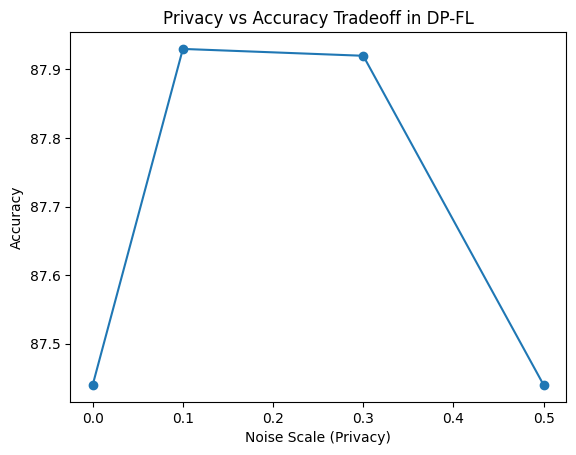

In [ ]:
plt.plot(noise_levels,results,marker='o')

plt.xlabel("Noise Scale (Privacy)")
plt.ylabel("Accuracy")

plt.title("Privacy vs Accuracy Tradeoff in DP-FL")

plt.show()